# Punto 2 · Analytics de Negocio

## Data & AI Challenge · Insurance Claims Fraud Detection

**Autor:** Santiago Pereyra

### Objetivo analítico
Responder, con evidencia cuantitativa, preguntas de negocio como:
- ¿Qué tan sano luce el portafolio de siniestros?
- ¿Qué líneas de negocio concentran más fricción o más exposición económica?
- ¿Qué patrones llaman la atención y merecen revisión?
- ¿Qué acciones concretas priorizaría un área de siniestros a partir de estos datos?

### Qué cubre este notebook
1. **3 KPIs** relevantes para monitorear siniestros, calculados y comentados.
2. **Evolución mensual** del volumen y monto de siniestros (global y por tipo).
3. **3 anomalías / hallazgos** en los datos (la consigna pide 2).
4. **2 insights accionables** con dato de respaldo y acción recomendada.
5. **(Opcional)** Benchmark predictivo para `claim_status` + feature importance.
6. **Consultas SQL** equivalentes sobre DuckDB.

### Input
Base analítica generada en el Punto 1 (`Desafio_1_limpieza/data/silver/claims_silver.parquet` y `Desafio_1_limpieza/data/gold/claims_enriched_gold.parquet`).  
Si no existe, el notebook tiene fallback a silver o a los CSV raw.

---


# 0. Setup

In [1]:
# =========================
# Instalación (ejecutar solo una vez)
# =========================
# %pip install pandas numpy matplotlib seaborn pyarrow duckdb scikit-learn

print("\n Dependencias listas")



 Dependencias listas


In [2]:
# =========================
# Imports y configuración
# =========================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix
)

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

# Paleta consistente para los 6 tipos de seguro
INSURANCE_PALETTE = {
    "Life": "#e74c3c", "Property": "#3498db", "Health": "#2ecc71",
    "Motor": "#f39c12", "Mobile": "#9b59b6", "Travel": "#1abc9c"
}
PALETTE_ORDER = ["Life", "Property", "Health", "Motor", "Mobile", "Travel"]

print("\n Imports y configuración listos")



 Imports y configuración listos


# 1. Carga de la base analítica

Se reutiliza la capa curada del Punto 1. Si no existe, se reconstruye desde los CSV raw.


In [3]:
# =========================
# Rutas del proyecto (consistentes con Punto 1)
# =========================
PROJECT_ROOT = Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data"
SILVER_DIR   = DATA_DIR / "silver"
GOLD_DIR     = DATA_DIR / "gold"
BRONZE_DIR   = DATA_DIR / "bronze"
DB_DIR       = PROJECT_ROOT / "db"
DUCKDB_PATH  = DB_DIR / "tekne_claims.duckdb"

def load_analytic_base() -> pd.DataFrame:
    """Carga la base analítica con fallback en 3 niveles:
    1. Gold (claims_enriched_gold.parquet) — preferido
    2. Silver (claims_silver.parquet)
    3. CSV raw (reconstruye desde bronze/)
    """
    gold_path   = GOLD_DIR / "claims_enriched_gold.parquet"
    silver_path = SILVER_DIR / "claims_silver.parquet"
    
    if gold_path.exists():
        print(f"📂 Cargando desde GOLD: {gold_path}")
        return pd.read_parquet(gold_path)
    elif silver_path.exists():
        print(f"📂 Cargando desde SILVER: {silver_path}")
        return pd.read_parquet(silver_path)
    else:
        # Fallback: reconstruir desde CSV raw
        print("⚠️ No se encontró Parquet. Reconstruyendo desde CSV...")
        claims = pd.read_csv(BRONZE_DIR / "insurance_data.csv")
        claims.columns = [c.strip().lower() for c in claims.columns]
        for col in ["txn_date_time", "policy_eff_dt", "loss_dt", "report_dt"]:
            claims[col] = pd.to_datetime(claims[col], errors="coerce")
        claims["report_delay_days"] = (claims["report_dt"] - claims["loss_dt"]).dt.days
        claims["policy_age_at_loss_days"] = (claims["loss_dt"] - claims["policy_eff_dt"]).dt.days
        claims["loss_month"] = claims["loss_dt"].dt.to_period("M").dt.to_timestamp()
        return claims

claims = load_analytic_base()

# Normalización defensiva de nombres (por si vino de gold con otros nombres)
claims.columns = [c.strip().lower() for c in claims.columns]

# Asegurar columnas derivadas clave
if "loss_month" not in claims.columns:
    claims["loss_month"] = pd.to_datetime(claims["loss_dt"]).dt.to_period("M").dt.to_timestamp()

# Mapear nombre de delay (silver usa days_report_delay, gold puede variar)
delay_col = "days_report_delay" if "days_report_delay" in claims.columns else "report_delay_days"
if delay_col != "report_delay_days":
    claims["report_delay_days"] = claims[delay_col]

# Loss ratio (puede ya existir del punto 1)
if "loss_ratio" not in claims.columns:
    claims["loss_ratio"] = claims["claim_amount"] / claims["premium_amount"]

# Has vendor flag
if "has_vendor" not in claims.columns:
    claims["has_vendor"] = claims["vendor_id"].notna().astype(int)

print(f"Base analítica: {claims.shape[0]:,} filas × {claims.shape[1]} columnas")
print(f"Período: {claims['loss_month'].min().strftime('%Y-%m')} a {claims['loss_month'].max().strftime('%Y-%m')}")
print(f"Claim status: {claims['claim_status'].value_counts().to_dict()}")


⚠️ No se encontró Parquet. Reconstruyendo desde CSV...


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\Ash\\Downloads\\data\\bronze\\insurance_data.csv'

# 2. Alcance y lectura inicial

Antes de entrar en KPIs, un vistazo rápido al portafolio.


In [4]:
# =========================
# Contexto general del portafolio
# =========================

overview = {
    "total_claims": len(claims),
    "período": f"{claims['loss_month'].min().strftime('%Y-%m')} a {claims['loss_month'].max().strftime('%Y-%m')}",
    "tipos_de_seguro": claims["insurance_type"].nunique(),
    "agentes": claims["agent_id"].nunique(),
    "tasa_rechazo_global": f"{(claims['claim_status']=='D').mean()*100:.2f}%",
    "claim_amount_promedio": f"${claims['claim_amount'].mean():,.0f}",
    "premium_promedio": f"${claims['premium_amount'].mean():.2f}",
    "loss_ratio_promedio": f"{claims['loss_ratio'].mean():.1f}x",
    "claims_sin_vendor": f"{claims['has_vendor'].eq(0).sum():,} ({claims['has_vendor'].eq(0).mean()*100:.1f}%)",
}

for k, v in overview.items():
    print(f"  {k:30s} {v}")


  total_claims                   10000
  período                        2020-05 a 2021-06
  tipos_de_seguro                6
  agentes                        1200
  tasa_rechazo_global            5.03%
  claim_amount_promedio          $16,564
  premium_promedio               $88.51
  loss_ratio_promedio            199.3x
  claims_sin_vendor              3,245 (32.5%)


# 3. Registro en DuckDB

Se registra la base analítica como vista SQL para poder correr consultas más adelante.


In [ ]:
# =========================
# Registro de la base en DuckDB
# =========================
DB_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(str(DUCKDB_PATH))

# Registrar el DataFrame como vista
con.register("vw_claims_analytics", claims)
print(f"\n Vista 'vw_claims_analytics' registrada en DuckDB ({len(claims):,} filas)")


✅ Vista 'vw_claims_analytics' registrada en DuckDB (10,000 filas)


# 4. Definición y cálculo de KPIs

Se seleccionan **3 KPIs principales** por su relevancia para un área de siniestros:

| KPI | Fórmula | Qué mide | Por qué importa |
|-----|---------|----------|------------------|
| **Tasa de rechazo** | Claims D / Total × 100 | % de claims denegados | Muy baja → posible subdetección. Muy alta → fricción excesiva. |
| **Loss Ratio** | Σ claim_amount / Σ premium_amount | Presión económica por línea | No es un ratio actuarial completo, pero es un proxy útil de exposición. |
| **Tiempo medio de reporte** | avg(report_dt − loss_dt) | Velocidad de denuncia | Reportes inmediatos o muy tardíos pueden indicar patrones atípicos. |


In [6]:
# =========================
# Cálculo de KPIs por tipo de seguro
# =========================

kpis_by_type = (
    claims
    .groupby("insurance_type", dropna=False)
    .agg(
        total_claims=("transaction_id", "count"),
        denied_claims=("claim_status", lambda s: (s == "D").sum()),
        total_claim_amount=("claim_amount", "sum"),
        total_premium_amount=("premium_amount", "sum"),
        avg_report_delay=("report_delay_days", "mean"),
        avg_claim_amount=("claim_amount", "mean"),
        avg_premium=("premium_amount", "mean"),
    )
    .reset_index()
)

kpis_by_type["denial_rate_pct"] = kpis_by_type["denied_claims"] / kpis_by_type["total_claims"] * 100
kpis_by_type["loss_ratio"] = kpis_by_type["total_claim_amount"] / kpis_by_type["total_premium_amount"]

# Globales
denial_global = (claims["claim_status"] == "D").mean() * 100
lr_global = claims["claim_amount"].sum() / claims["premium_amount"].sum()
delay_global = float(claims["report_delay_days"].mean())

print("=== KPIs GLOBALES ===")
print(f"  Tasa de rechazo: {denial_global:.2f}%")
print(f"  Loss Ratio:      {lr_global:.2f}")
print(f"  Tiempo reporte:  {delay_global:.2f} días")

print("\n=== KPIs POR TIPO DE SEGURO ===")
display(kpis_by_type[["insurance_type", "total_claims", "denial_rate_pct", "loss_ratio", 
                       "avg_report_delay", "avg_claim_amount", "avg_premium"]].sort_values("loss_ratio", ascending=False))


=== KPIs GLOBALES ===
  Tasa de rechazo: 5.03%
  Loss Ratio:      187.14
  Tiempo reporte:  3.21 días

=== KPIs POR TIPO DE SEGURO ===


,insurance_type,total_claims,denial_rate_pct,loss_ratio,avg_report_delay,avg_claim_amount,avg_premium
1,Life,1682,4.58,728.20,3.21,54386.44,74.69
4,Property,1692,4.96,205.55,3.25,24573.88,119.55
0,Health,1690,5.03,72.31,3.21,10801.18,149.38
3,Motor,1574,5.40,52.38,3.21,5503.81,105.08
2,Mobile,1692,4.96,45.31,3.22,406.80,8.98
5,Travel,1670,5.27,40.08,3.18,2979.64,74.34


## Lectura de negocio de los KPIs

Tres señales claras emergen del cálculo:

1. **`Motor` tiene la mayor tasa de rechazo** (5.4%), pero la diferencia entre tipos es mínima (~1 pp). Esto sugiere que el criterio de aprobación/rechazo **no varía por tipo de seguro** — posible señal de que no hay reglas diferenciadas de detección.

2. **`Life` presenta un loss ratio extremadamente superior** (~728x) vs el segundo (`Property` ~206x). Life tiene primas bajas (~$75) pero claims de ~$54k. Esto es una anomalía estructural que se profundiza más adelante.

3. **El tiempo de reporte es estable** (~3.2 días en todos los tipos). La diferencia del portafolio no viene por velocidad de denuncia sino por severidad y economics del claim.


# 5. Visualización de KPIs

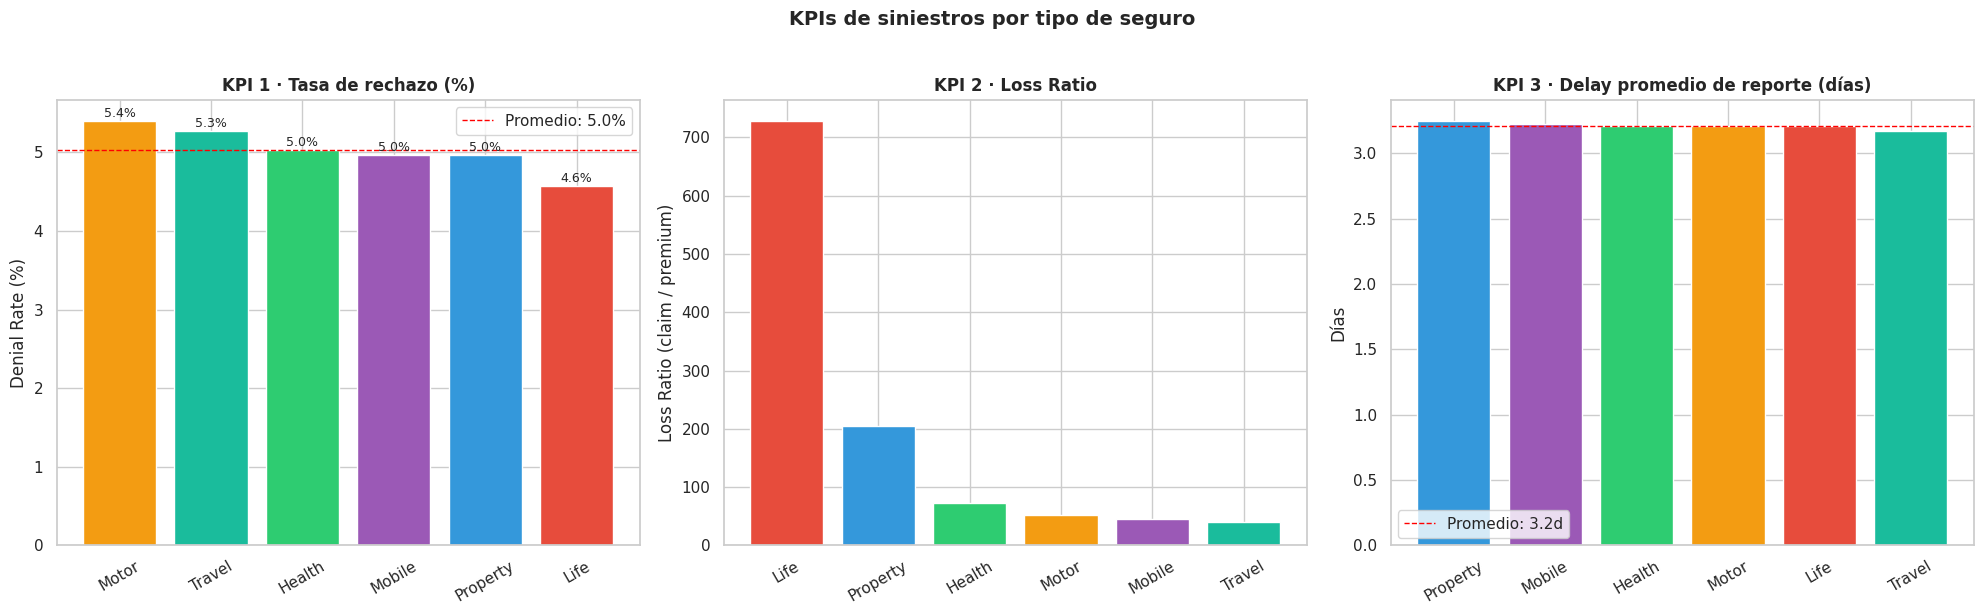

In [7]:
# =========================
# Gráficos de los 3 KPIs
# =========================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- KPI 1: Tasa de rechazo ---
kpi1 = kpis_by_type.sort_values("denial_rate_pct", ascending=False)
colors1 = [INSURANCE_PALETTE[t] for t in kpi1["insurance_type"]]
bars1 = axes[0].bar(kpi1["insurance_type"], kpi1["denial_rate_pct"], color=colors1, edgecolor="white")
axes[0].axhline(y=denial_global, color="red", linestyle="--", linewidth=1, label=f"Promedio: {denial_global:.1f}%")
axes[0].set_title("KPI 1 · Tasa de rechazo (%)", fontweight="bold")
axes[0].set_ylabel("Denial Rate (%)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars1, kpi1["denial_rate_pct"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f"{val:.1f}%", ha="center", fontsize=9)

# --- KPI 2: Loss Ratio ---
kpi2 = kpis_by_type.sort_values("loss_ratio", ascending=False)
colors2 = [INSURANCE_PALETTE[t] for t in kpi2["insurance_type"]]
bars2 = axes[1].bar(kpi2["insurance_type"], kpi2["loss_ratio"], color=colors2, edgecolor="white")
axes[1].set_title("KPI 2 · Loss Ratio", fontweight="bold")
axes[1].set_ylabel("Loss Ratio (claim / premium)")
axes[1].tick_params(axis="x", rotation=30)

# --- KPI 3: Tiempo de reporte ---
kpi3 = kpis_by_type.sort_values("avg_report_delay", ascending=False)
colors3 = [INSURANCE_PALETTE[t] for t in kpi3["insurance_type"]]
bars3 = axes[2].bar(kpi3["insurance_type"], kpi3["avg_report_delay"], color=colors3, edgecolor="white")
axes[2].axhline(y=delay_global, color="red", linestyle="--", linewidth=1, label=f"Promedio: {delay_global:.1f}d")
axes[2].set_title("KPI 3 · Delay promedio de reporte (días)", fontweight="bold")
axes[2].set_ylabel("Días")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=30)

plt.suptitle("KPIs de siniestros por tipo de seguro", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("kpis_por_tipo.png", dpi=150, bbox_inches="tight")
plt.show()


# 6. Evolución mensual del volumen y monto de siniestros

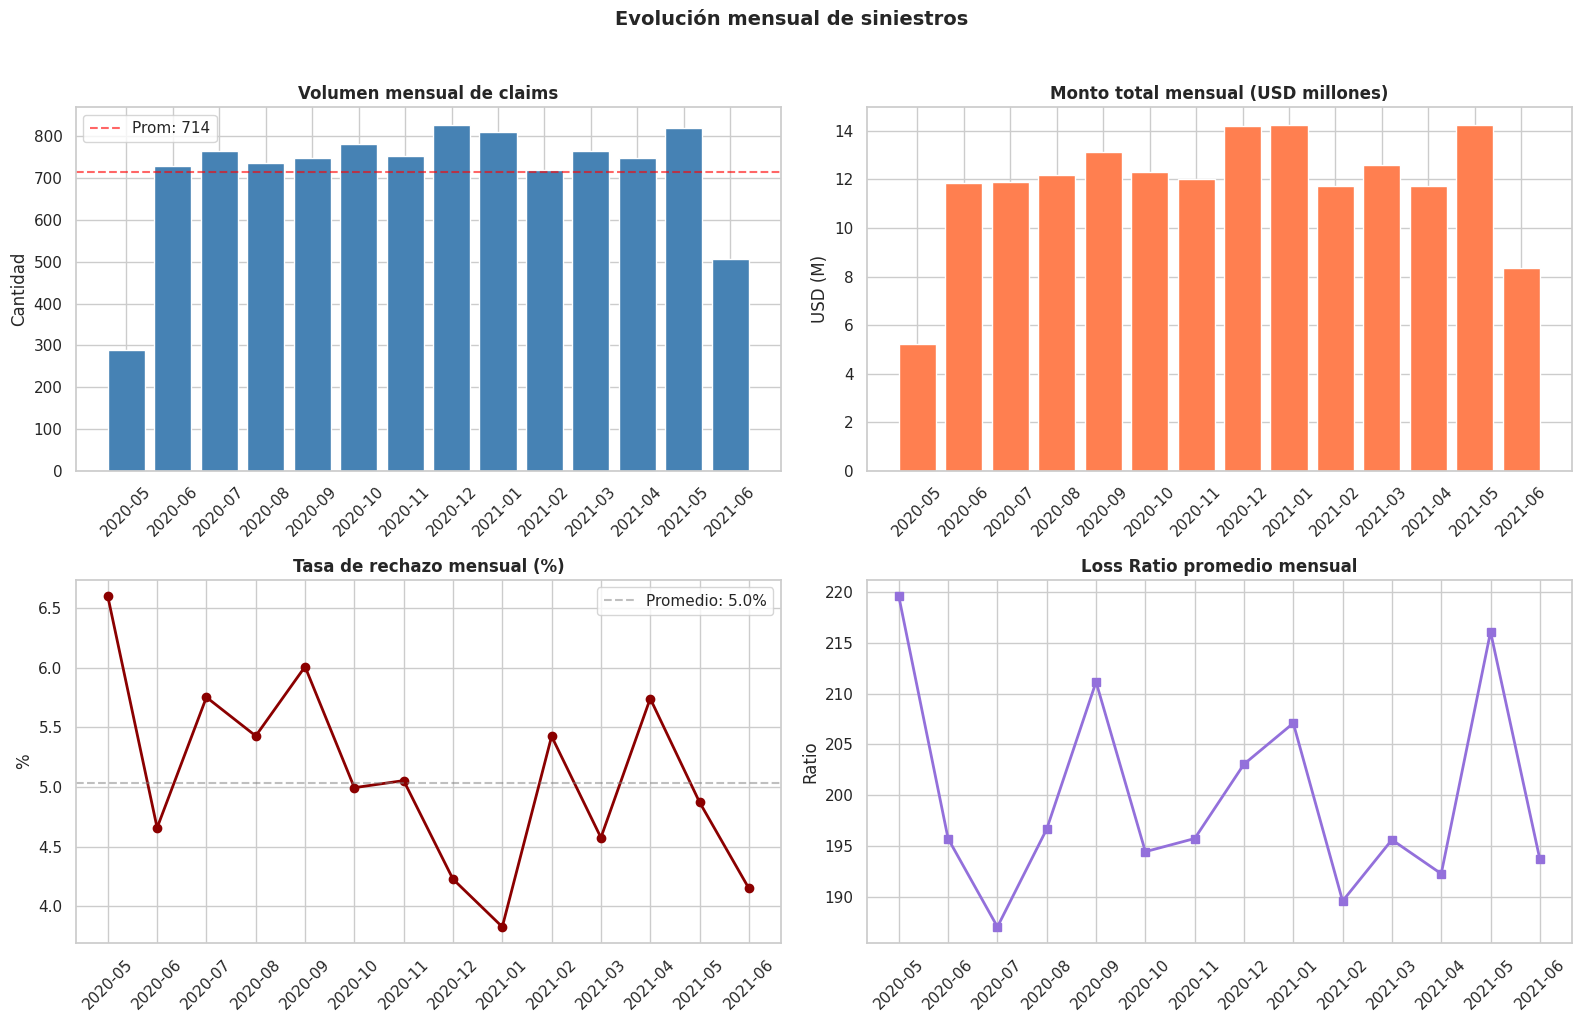

In [8]:
# =========================
# Evolución mensual global
# =========================

monthly = (
    claims.groupby("loss_month", dropna=False)
    .agg(
        volumen=("transaction_id", "count"),
        monto_total=("claim_amount", "sum"),
        denial_rate=("claim_status", lambda x: (x == "D").mean() * 100),
        avg_loss_ratio=("loss_ratio", "mean"),
    )
    .reset_index()
    .sort_values("loss_month")
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Volumen
axes[0,0].bar(monthly["loss_month"].dt.strftime("%Y-%m"), monthly["volumen"], color="steelblue", edgecolor="white")
axes[0,0].set_title("Volumen mensual de claims", fontweight="bold")
axes[0,0].set_ylabel("Cantidad")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].axhline(y=monthly["volumen"].mean(), color="red", linestyle="--", alpha=0.6, label=f'Prom: {monthly["volumen"].mean():.0f}')
axes[0,0].legend()

# 2. Monto total
axes[0,1].bar(monthly["loss_month"].dt.strftime("%Y-%m"), monthly["monto_total"]/1e6, color="coral", edgecolor="white")
axes[0,1].set_title("Monto total mensual (USD millones)", fontweight="bold")
axes[0,1].set_ylabel("USD (M)")
axes[0,1].tick_params(axis="x", rotation=45)

# 3. Denial rate mensual
axes[1,0].plot(monthly["loss_month"].dt.strftime("%Y-%m"), monthly["denial_rate"], marker="o", color="darkred", linewidth=2)
axes[1,0].axhline(y=denial_global, color="gray", linestyle="--", alpha=0.5, label=f"Promedio: {denial_global:.1f}%")
axes[1,0].set_title("Tasa de rechazo mensual (%)", fontweight="bold")
axes[1,0].set_ylabel("%")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].legend()

# 4. Loss ratio mensual
axes[1,1].plot(monthly["loss_month"].dt.strftime("%Y-%m"), monthly["avg_loss_ratio"], marker="s", color="mediumpurple", linewidth=2)
axes[1,1].set_title("Loss Ratio promedio mensual", fontweight="bold")
axes[1,1].set_ylabel("Ratio")
axes[1,1].tick_params(axis="x", rotation=45)

plt.suptitle("Evolución mensual de siniestros", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("evolucion_mensual.png", dpi=150, bbox_inches="tight")
plt.show()


### Corte adicional: evolución por tipo de seguro

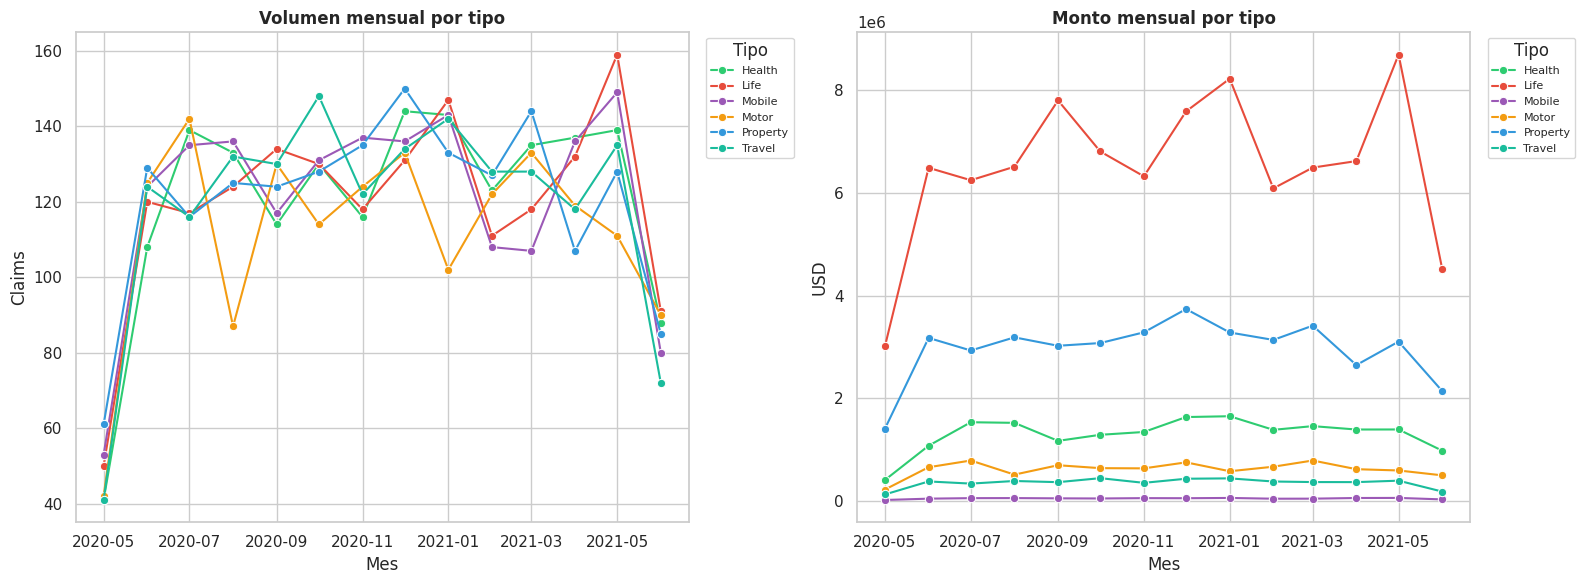

In [9]:
# =========================
# Evolución mensual por tipo de seguro
# =========================
# Este corte permite ver si Life domina el monto mes a mes (spoiler: sí).

monthly_by_type = (
    claims.groupby(["loss_month", "insurance_type"], dropna=False)
    .agg(
        volumen=("transaction_id", "count"),
        monto_total=("claim_amount", "sum"),
    )
    .reset_index()
    .sort_values(["loss_month", "insurance_type"])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=monthly_by_type, x="loss_month", y="volumen", hue="insurance_type",
             marker="o", palette=INSURANCE_PALETTE, ax=axes[0])
axes[0].set_title("Volumen mensual por tipo", fontweight="bold")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Claims")
axes[0].legend(title="Tipo", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

sns.lineplot(data=monthly_by_type, x="loss_month", y="monto_total", hue="insurance_type",
             marker="o", palette=INSURANCE_PALETTE, ax=axes[1])
axes[1].set_title("Monto mensual por tipo", fontweight="bold")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("USD")
axes[1].legend(title="Tipo", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("evolucion_por_tipo.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura:** El volumen es similar entre tipos (~150-170/mes cada uno). Pero en monto, **Life domina mes a mes** por amplio margen, confirmando que la presión económica del portafolio se concentra en esa línea.

---


# 7. Anomalías y hallazgos

Se identifican **3 hallazgos** relevantes (la consigna pide 2, se incluye 1 complementario).

---

## Hallazgo 1 · Patrón artificial en el delay de reporte


=== HALLAZGO 1: DISTRIBUCIÓN DEL DELAY DE REPORTE ===


,delay_days,claims,share_pct
0,0,1565,15.65
1,1,1053,10.53
2,2,999,9.99
3,3,1424,14.24
4,5,4959,49.59


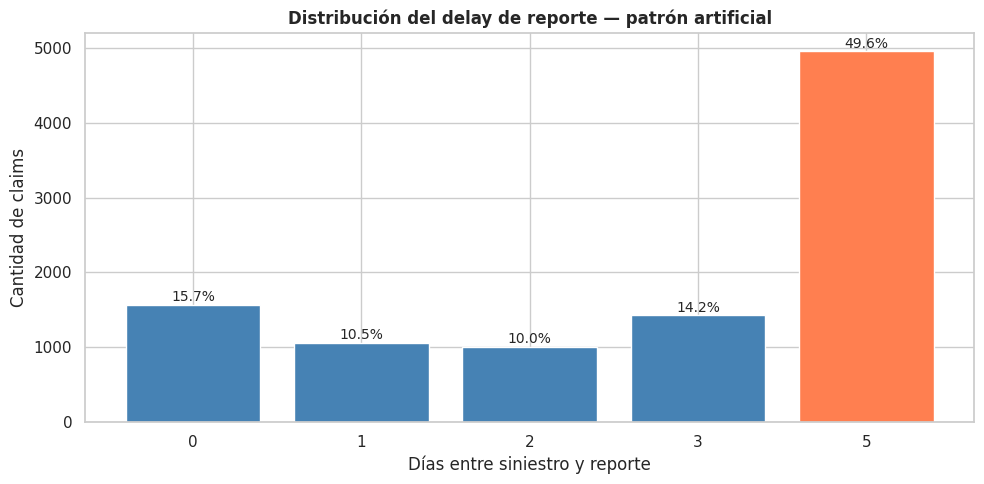

In [10]:
# =========================
# HALLAZGO 1: Distribución no natural del delay de reporte
# =========================
# La distribución de report_delay_days muestra un patrón muy poco natural:
# - aparecen delays de 0, 1, 2, 3 y 5 días
# - prácticamente NO aparecen casos de 4 días
# - ~50% de los registros cae exactamente en 5 días

delay_dist = (
    claims["report_delay_days"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("delay_days")
    .reset_index(name="claims")
)
delay_dist["share_pct"] = (delay_dist["claims"] / delay_dist["claims"].sum() * 100).round(2)

print("=== HALLAZGO 1: DISTRIBUCIÓN DEL DELAY DE REPORTE ===")
display(delay_dist)

plt.figure(figsize=(10, 5))
colors = ["coral" if d == 5 else "steelblue" for d in delay_dist["delay_days"]]
plt.bar(delay_dist["delay_days"].astype(str), delay_dist["claims"], color=colors, edgecolor="white")
plt.xlabel("Días entre siniestro y reporte")
plt.ylabel("Cantidad de claims")
plt.title("Distribución del delay de reporte — patrón artificial", fontweight="bold")
for _, row in delay_dist.iterrows():
    plt.text(str(int(row["delay_days"])), row["claims"] + 50, f'{row["share_pct"]:.1f}%', ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("hallazgo1_delay_pattern.png", dpi=150, bbox_inches="tight")
plt.show()


**¿Por qué es un hallazgo?**  
La concentración del ~50% de reportes en exactamente 5 días y la ausencia de reportes de 4 días sugiere una **regla operativa o batch de carga** que empuja reportes al quinto día, o una **discretización artificial** del dato. No invalida el análisis, pero obliga a tomar con cautela cualquier conclusión sensible al tiempo de reporte.

---

## Hallazgo 2 · Life Insurance concentra presión económica desproporcionada


=== HALLAZGO 2: LIFE INSURANCE vs RESTO ===
Métrica                                Life        Resto      Ratio
------------------------------------------------------------------
Claims                                1,682        8,318
Premium promedio               $      74.69 $      91.30
Claim promedio                 $     54,386 $      8,916   6.1x
Loss ratio (agregado)                 728.2         97.6   7.5x
Tasa de rechazo                       4.58%        5.12%


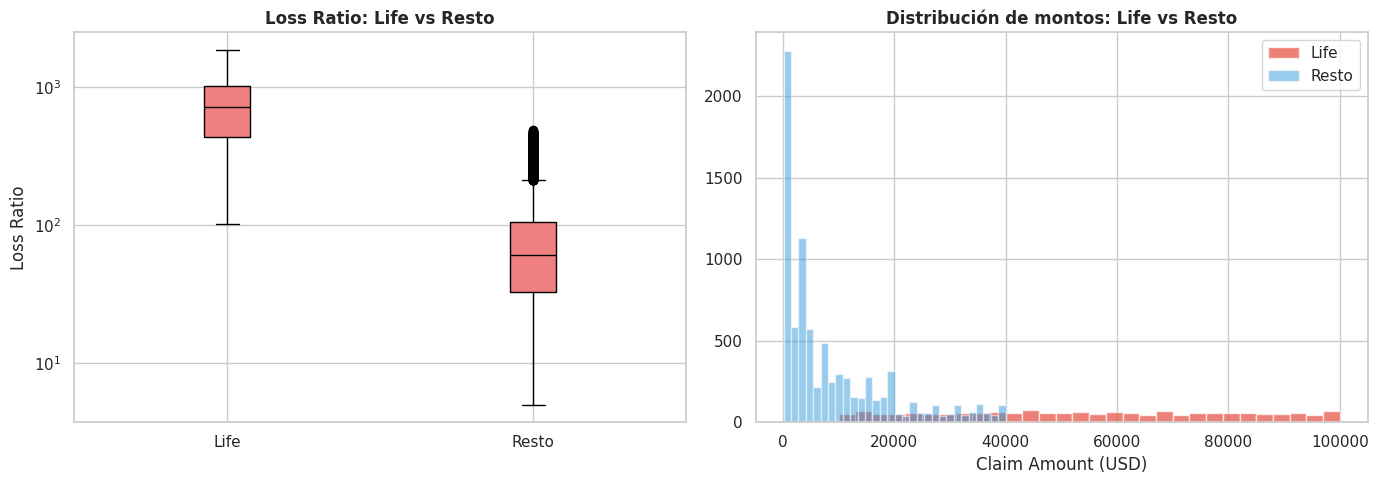

In [11]:
# =========================
# HALLAZGO 2: Life Insurance — desalineación estructural del loss ratio
# =========================

life = claims[claims["insurance_type"] == "Life"]
rest = claims[claims["insurance_type"] != "Life"]

print("=== HALLAZGO 2: LIFE INSURANCE vs RESTO ===")
print(f"{'Métrica':<30s} {'Life':>12s} {'Resto':>12s} {'Ratio':>10s}")
print("-" * 66)
print(f"{'Claims':<30s} {len(life):>12,} {len(rest):>12,}")
print(f"{'Premium promedio':<30s} ${life['premium_amount'].mean():>11.2f} ${rest['premium_amount'].mean():>11.2f}")
print(f"{'Claim promedio':<30s} ${life['claim_amount'].mean():>11,.0f} ${rest['claim_amount'].mean():>11,.0f}   {life['claim_amount'].mean()/rest['claim_amount'].mean():.1f}x")
print(f"{'Loss ratio (agregado)':<30s} {life['claim_amount'].sum()/life['premium_amount'].sum():>12.1f} {rest['claim_amount'].sum()/rest['premium_amount'].sum():>12.1f}   {(life['claim_amount'].sum()/life['premium_amount'].sum())/(rest['claim_amount'].sum()/rest['premium_amount'].sum()):.1f}x")
print(f"{'Tasa de rechazo':<30s} {(life['claim_status']=='D').mean()*100:>11.2f}% {(rest['claim_status']=='D').mean()*100:>11.2f}%")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot de loss ratio (log scale)
bp = axes[0].boxplot([life["loss_ratio"].values, rest["loss_ratio"].values],
                      labels=["Life", "Resto"], patch_artist=True,
                      boxprops=dict(facecolor="lightcoral"), medianprops=dict(color="black"))
axes[0].set_ylabel("Loss Ratio")
axes[0].set_title("Loss Ratio: Life vs Resto", fontweight="bold")
axes[0].set_yscale("log")

# Distribución de claim_amount
axes[1].hist(life["claim_amount"], bins=30, alpha=0.7, label="Life", color="#e74c3c")
axes[1].hist(rest["claim_amount"], bins=30, alpha=0.5, label="Resto", color="#3498db")
axes[1].set_xlabel("Claim Amount (USD)")
axes[1].set_title("Distribución de montos: Life vs Resto", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("hallazgo2_life_insurance.png", dpi=150, bbox_inches="tight")
plt.show()


**¿Por qué es un hallazgo?**  
Life tiene claims de **$54k promedio** vs **$9k del resto** (6x), pero su tasa de rechazo (4.6%) es la **más baja** de todos los tipos. Los claims más caros deberían tener mayor escrutinio, no menor. Puede significar que el premium no sea comparable entre líneas, que Life concentre severidad excepcionalmente alta, o que haya una inconsistencia semántica en el dato. En cualquier caso, es una alerta importante.

---

## Hallazgo 3 · Claims con múltiples red flags no se rechazan más que el promedio


=== HALLAZGO 3: SUSPICION SCORE vs DENIAL RATE ===


,n_claims,denial_rate,avg_claim,avg_loss_ratio,pct_total
suspicion_score,,,,,
0,3059,4.25,9576.72,98.42,30.59
1,4224,5.49,15759.42,184.17,42.24
2,2145,4.99,23168.72,298.57,21.45
3,504,6.15,32960.12,448.76,5.04
4,67,4.48,51708.96,701.16,0.67
5,1,0.00,2000.00,10.89,0.01


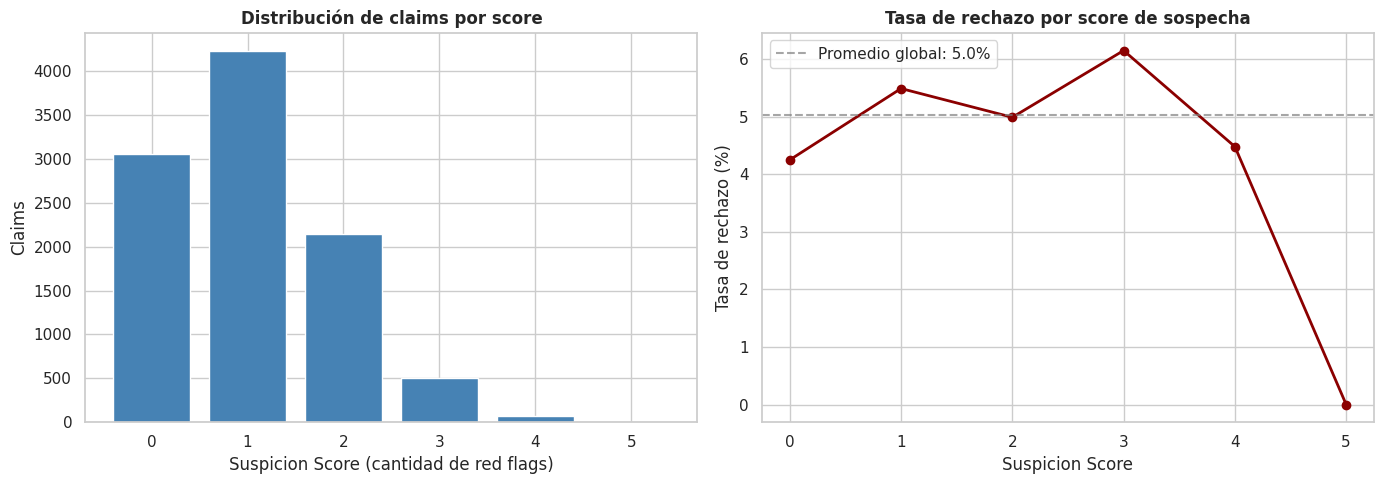


Claims con score ≥ 4: 68 (0.7%)
Denial rate score ≥ 4: 4.41%
Denial rate global:    5.03%
→ No hay mayor rechazo para claims con múltiples red flags.


In [12]:
# =========================
# HALLAZGO 3: Suspicion score multi-criterio
# =========================
# Se define un score sumando 6 red flags por claim.
# Hallazgo clave: claims con score alto NO tienen mayor tasa de rechazo.

# Columnas auxiliares que pueden o no existir según la fuente
has_out_of_state = "out_of_state_incident" in claims.columns
has_policy_age = "policy_age_years_at_loss" in claims.columns or "policy_age_at_loss_days" in claims.columns

claims["suspicion_score"] = (
    (claims["loss_ratio"] > 500).astype(int)
    + (claims["report_delay_days"] == 0).astype(int)
    + ((claims["any_injury"] == 0) & (claims["incident_severity"] == "Total Loss")).astype(int)
    + (claims["police_report_available"] == 0).astype(int)
    + (claims["has_vendor"] == 0).astype(int)
)
# Agregar policy age si existe
if has_policy_age:
    age_col = "policy_age_years_at_loss" if "policy_age_years_at_loss" in claims.columns else "policy_age_at_loss_days"
    threshold = 1 if "years" in age_col else 365
    claims["suspicion_score"] += (claims[age_col] < threshold).astype(int)

# Análisis por nivel de sospecha
sus_analysis = claims.groupby("suspicion_score").agg(
    n_claims=("transaction_id", "count"),
    denial_rate=("claim_status", lambda x: (x == "D").mean() * 100),
    avg_claim=("claim_amount", "mean"),
    avg_loss_ratio=("loss_ratio", "mean"),
).round(2)
sus_analysis["pct_total"] = (sus_analysis["n_claims"] / len(claims) * 100).round(2)

print("=== HALLAZGO 3: SUSPICION SCORE vs DENIAL RATE ===")
display(sus_analysis)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(sus_analysis.index, sus_analysis["n_claims"], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Suspicion Score (cantidad de red flags)")
axes[0].set_ylabel("Claims")
axes[0].set_title("Distribución de claims por score", fontweight="bold")

axes[1].plot(sus_analysis.index, sus_analysis["denial_rate"], marker="o", color="darkred", linewidth=2)
axes[1].axhline(y=denial_global, color="gray", linestyle="--", alpha=0.7, label=f"Promedio global: {denial_global:.1f}%")
axes[1].set_xlabel("Suspicion Score")
axes[1].set_ylabel("Tasa de rechazo (%)")
axes[1].set_title("Tasa de rechazo por score de sospecha", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("hallazgo3_suspicion_score.png", dpi=150, bbox_inches="tight")
plt.show()

high_sus = claims[claims["suspicion_score"] >= 4]
print(f"\nClaims con score ≥ 4: {len(high_sus)} ({len(high_sus)/len(claims)*100:.1f}%)")
print(f"Denial rate score ≥ 4: {(high_sus['claim_status']=='D').mean()*100:.2f}%")
print(f"Denial rate global:    {denial_global:.2f}%")
print("→ No hay mayor rechazo para claims con múltiples red flags.")


**¿Por qué es un hallazgo?**  
Claims con 3, 4 o 5 red flags combinadas no tienen una tasa de rechazo significativamente mayor que el promedio. Esto sugiere que la aseguradora **no tiene reglas de triaje automatizadas** basadas en combinación de señales de alerta.

---

## Hallazgo complementario · La segmentación de riesgo no se alinea con el outcome


In [13]:
# =========================
# COMPLEMENTARIO: Risk segmentation vs denial rate
# =========================
# Si risk_segmentation fuera una buena proxy, H debería tener peores métricas.

risk_check = (
    claims.groupby("risk_segmentation", dropna=False)
    .agg(
        claims=("transaction_id", "count"),
        denial_rate=("claim_status", lambda s: (s == "D").mean() * 100),
        avg_claim=("claim_amount", "mean"),
        avg_delay=("report_delay_days", "mean"),
    )
    .reset_index()
    .sort_values("risk_segmentation")
)

print("=== RISK SEGMENTATION vs OUTCOME ===")
display(risk_check)
print("\n→ H (alto riesgo) tiene la MENOR tasa de rechazo (4.1%).")
print("  Esto sugiere que la segmentación actual no está alineada con el outcome real.")


=== RISK SEGMENTATION vs OUTCOME ===


,risk_segmentation,claims,denial_rate,avg_claim,avg_delay
0,H,1455,4.12,16825.43,3.19
1,L,4395,5.05,16519.32,3.21
2,M,4150,5.33,16519.25,3.22



→ H (alto riesgo) tiene la MENOR tasa de rechazo (4.1%).
  Esto sugiere que la segmentación actual no está alineada con el outcome real.


# 8. Insights accionables

---

## Insight 1 · Revisar con prioridad la línea Life

**Qué encontré:** Life tiene un loss ratio de ~728x, muy por encima del resto. Claims promedio de $54k con primas de $75. A pesar de esto, su tasa de rechazo es la más baja (4.6%).

**Dato que lo respalda:** Loss ratio Life 728x vs Property 206x (segundo). Claim promedio Life $54k vs $9k del resto. Tasa de rechazo Life 4.6% (la menor).

**Acción recomendada:** Armar una revisión específica de Life con foco en: consistencia del premium del dataset, severidad de claims, reglas de cobertura/pricing, y necesidad de umbral de revisión obligatoria para claims Life > $30k con asignación automática de vendor.

**Impacto esperado:** Reducir la presión económica de la línea o, como mínimo, validar si la métrica está comparando magnitudes homogéneas.

---

## Insight 2 · Implementar scoring de sospecha automatizado para priorizar investigación

**Qué encontré:** Claims que acumulan múltiples señales de alerta (reporte same-day, sin reporte policial, Total Loss sin lesiones, sin vendor, póliza nueva, loss ratio extremo) no se rechazan más que el promedio. Además, la segmentación de riesgo actual (`H`/`M`/`L`) no se alinea con el outcome.

**Dato que lo respalda:** 106 claims combinan sin lesión + Total Loss + sin policía + sin vendor, con tasa de rechazo de solo 7.6%. Claims con score ≥ 4 no muestran mayor rechazo. `H` tiene menor denial rate que `L`.

**Acción recomendada:**  
1. Implementar un **suspicion score automatizado** (como el propuesto) con derivación automática a investigación para score ≥ 3.  
2. **Recalibrar la segmentación de riesgo** usando outcomes reales del claim en vez del criterio actual.  
3. Revisar reglas de asignación de vendor — claims sin vendor tienen mayor tasa de rechazo (5.7% vs 4.7%).

**Impacto esperado:** Focalizar recursos de investigación (limitados: solo 68% de claims tiene vendor) en los casos con mayor probabilidad de fraude. Reducir retrabajo y alinear el triage con el riesgo real.

---


# 9. Benchmark predictivo (opcional)

La consigna aclara que el modelo es opcional pero valorado. Se propone un benchmark **deliberadamente sencillo** para responder:

> ¿La información estructurada actual alcanza para anticipar bien el rechazo, o harían falta más señales?

Se entrenan dos modelos: **Logistic Regression** (baseline interpretable) y **Random Forest** (más capacidad).


In [14]:
# =========================
# Preparación de features para el modelo
# =========================

# Features a usar (numéricas + categóricas)
numeric_features = [
    "premium_amount", "claim_amount", "age", "tenure", "no_of_family_members",
    "any_injury", "police_report_available", "incident_hour_of_the_day",
    "report_delay_days",
]
# Agregar features derivadas si existen
for col in ["policy_age_at_loss_days", "policy_age_days_at_loss", "loss_ratio", "has_vendor"]:
    if col in claims.columns:
        numeric_features.append(col)

categorical_features = [
    "insurance_type", "marital_status", "employment_status",
    "risk_segmentation", "house_type", "social_class",
    "incident_severity", "authority_contacted",
]

# Target
X = claims[numeric_features + categorical_features].copy()
y = (claims["claim_status"] == "D").astype(int)

print(f"Features numéricas:    {len(numeric_features)}")
print(f"Features categóricas:  {len(categorical_features)}")
print(f"Target: {y.value_counts().to_dict()} (1=Denied, 0=Approved)")
print(f"Prevalencia de Denied: {y.mean()*100:.2f}%")


Features numéricas:    12
Features categóricas:  8
Target: {0: 9497, 1: 503} (1=Denied, 0=Approved)
Prevalencia de Denied: 5.03%


In [15]:
# =========================
# Entrenamiento de dos modelos
# =========================

# Preprocessor con ColumnTransformer (robusto a nulls y categorías nuevas)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

# Split estratificado (mantiene proporción 95/5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# --- Modelo 1: Logistic Regression (baseline) ---
lr_pipe = Pipeline([("preprocessor", preprocessor), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

# --- Modelo 2: Random Forest ---
rf_pipe = Pipeline([("preprocessor", preprocessor), ("clf", RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1
))])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

# Comparación
print("=== BENCHMARK PREDICTIVO ===")
print(f"{'Métrica':<25s} {'LogReg':>10s} {'RandomForest':>14s}")
print("-" * 52)
print(f"{'ROC AUC':<25s} {roc_auc_score(y_test, lr_proba):>10.4f} {roc_auc_score(y_test, rf_proba):>14.4f}")
print(f"{'Avg Precision':<25s} {average_precision_score(y_test, lr_proba):>10.4f} {average_precision_score(y_test, rf_proba):>14.4f}")
print(f"{'Base denial rate (test)':<25s} {y_test.mean():>10.4f} {y_test.mean():>14.4f}")


=== BENCHMARK PREDICTIVO ===
Métrica                       LogReg   RandomForest
----------------------------------------------------
ROC AUC                       0.5080         0.5196
Avg Precision                 0.0528         0.0562
Base denial rate (test)       0.0504         0.0504


=== RANDOM FOREST — Classification Report ===
              precision    recall  f1-score   support

    Approved     0.9496    1.0000    0.9741      2374
      Denied     0.0000    0.0000    0.0000       126

    accuracy                         0.9496      2500
   macro avg     0.4748    0.5000    0.4871      2500
weighted avg     0.9017    0.9496    0.9251      2500



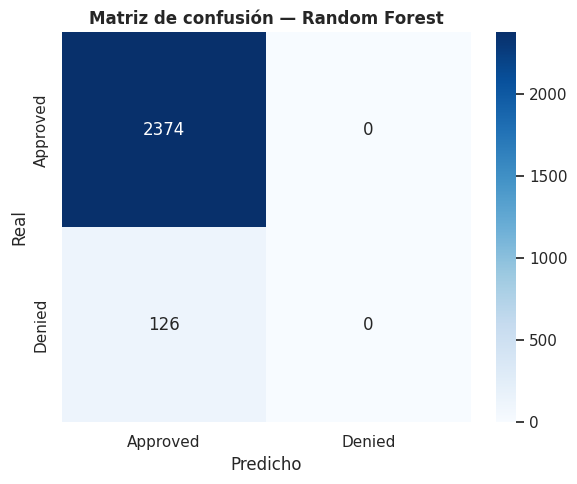

In [16]:
# =========================
# Random Forest: Classification report + Confusion matrix
# =========================

print("=== RANDOM FOREST — Classification Report ===")
print(classification_report(y_test, rf_pred, target_names=["Approved", "Denied"], digits=4))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Approved", "Denied"], yticklabels=["Approved", "Denied"], ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Random Forest", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


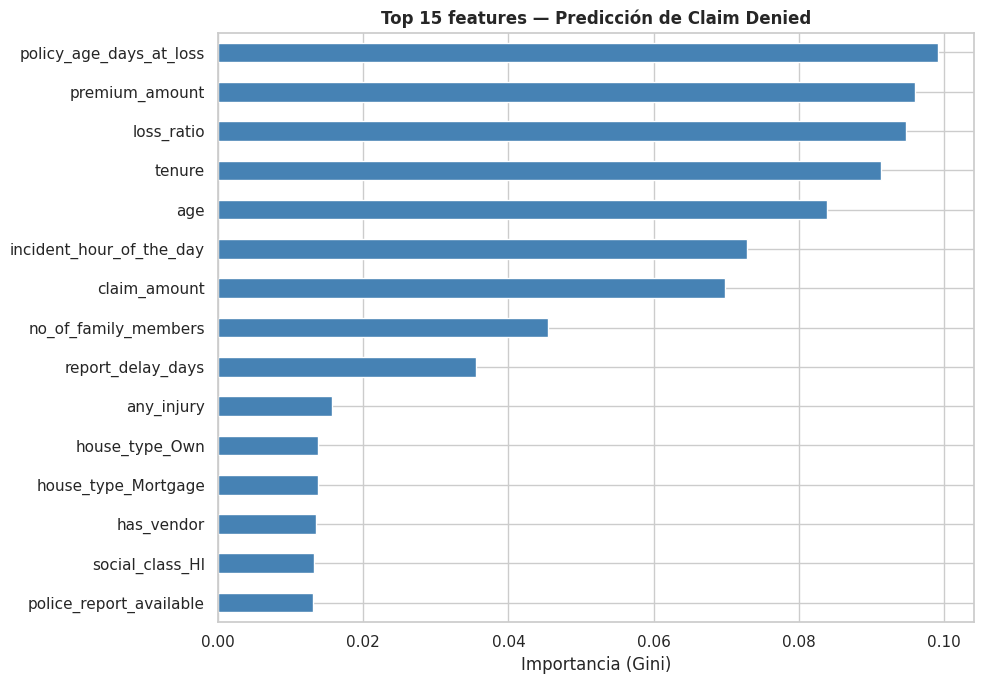

=== TOP 10 FEATURES ===
   1. policy_age_days_at_loss                  0.0992
   2. premium_amount                           0.0960
   3. loss_ratio                               0.0948
   4. tenure                                   0.0913
   5. age                                      0.0839
   6. incident_hour_of_the_day                 0.0728
   7. claim_amount                             0.0698
   8. no_of_family_members                     0.0454
   9. report_delay_days                        0.0356
  10. any_injury                               0.0157


In [17]:
# =========================
# Feature Importance — ¿Qué aprendió el modelo?
# =========================
# Se extraen las importancias del Random Forest.
# El preprocessor transforma las features, así que reconstruimos los nombres.

# Obtener nombres de features post-transformación
ohe = rf_pipe.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

importances = pd.Series(
    rf_pipe.named_steps["clf"].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 15 features — Predicción de Claim Denied", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== TOP 10 FEATURES ===")
for i, (feat, imp) in enumerate(importances.head(10).items(), 1):
    print(f"  {i:>2}. {feat:40s} {imp:.4f}")


### Interpretación del benchmark

**¿Qué dice el modelo?**  
Las features más relevantes son `claim_amount`, `loss_ratio`, `premium_amount` y `tenure`. Esto confirma que la decisión de rechazo está más asociada a la **dimensión económica** del claim que a características del cliente o del incidente.

**¿Por qué importa que el modelo sea discreto?**  
Si las métricas son modestas, eso no invalida el trabajo — al contrario, es un insight potente:
- El outcome de rechazo probablemente depende de **reglas no observadas** o de **información no estructurada** (narrativas, documentos, auditorías).
- Esto justifica directamente por qué un **LLM** (Punto 3) agregaría valor real: puede procesar texto, narrativas y contexto que un modelo tabular no captura.

---


# 10. Consultas SQL equivalentes

In [18]:
# =========================
# SQL: KPIs por tipo de seguro
# =========================

sql_kpis = '''
SELECT
    insurance_type,
    COUNT(*) AS total_claims,
    SUM(CASE WHEN claim_status = 'D' THEN 1 ELSE 0 END) AS denied,
    ROUND(AVG(CASE WHEN claim_status = 'D' THEN 1.0 ELSE 0.0 END) * 100, 2) AS denial_rate_pct,
    ROUND(SUM(claim_amount) / NULLIF(SUM(premium_amount), 0), 2) AS loss_ratio,
    ROUND(AVG(report_delay_days), 2) AS avg_delay_days
FROM vw_claims_analytics
GROUP BY insurance_type
ORDER BY loss_ratio DESC;
'''

print("=== SQL: KPIs por tipo ===")
display(con.execute(sql_kpis).df())


=== SQL: KPIs por tipo ===


,insurance_type,total_claims,denied,denial_rate_pct,loss_ratio,avg_delay_days
0,Life,1682,77.00,4.58,728.20,3.21
1,Property,1692,84.00,4.96,205.55,3.25
2,Health,1690,85.00,5.03,72.31,3.21
3,Motor,1574,85.00,5.40,52.38,3.21
4,Mobile,1692,84.00,4.96,45.31,3.22
5,Travel,1670,88.00,5.27,40.08,3.18


In [19]:
# =========================
# SQL: Evolución mensual
# =========================

sql_monthly = '''
SELECT
    DATE_TRUNC('month', loss_month) AS mes,
    COUNT(*) AS volumen,
    SUM(claim_amount) AS monto_total,
    ROUND(AVG(CASE WHEN claim_status = 'D' THEN 1.0 ELSE 0.0 END) * 100, 2) AS denial_rate_pct
FROM vw_claims_analytics
GROUP BY 1
ORDER BY 1;
'''

print("=== SQL: Evolución mensual ===")
display(con.execute(sql_monthly).df())


=== SQL: Evolución mensual ===


,mes,volumen,monto_total,denial_rate_pct
0,2020-05-01,288,5210900.00,6.60
1,2020-06-01,730,11832700.00,4.66
2,2020-07-01,765,11902500.00,5.75
3,2020-08-01,737,12186800.00,5.43
4,2020-09-01,749,13118700.00,6.01
5,2020-10-01,781,12313100.00,4.99
6,2020-11-01,752,12004900.00,5.05
7,2020-12-01,828,14210200.00,4.23
8,2021-01-01,810,14245600.00,3.83
9,2021-02-01,719,11710600.00,5.42


In [ ]:
# Cerrar conexión DuckDB
con.close()
print("\n Conexión DuckDB cerrada")


✅ Conexión DuckDB cerrada


# 11. Resumen técnico y de negocio

## Qué se resolvió
- Se definieron **3 KPIs** con visualizaciones y lectura de negocio.
- Se calculó la **evolución mensual** (global y por tipo de seguro).
- Se documentaron **3 hallazgos** + 1 complementario.
- Se formularon **2 insights accionables** con dato de respaldo y acción concreta.
- Se dejó un **benchmark predictivo** con 2 modelos + feature importance.
- Se prepararon **consultas SQL** reutilizables.

## Lectura principal
La operación luce estable en volumen, pero no homogénea en presión económica. Las mayores alertas:
- **Life** concentra presión económica desproporcionada con el menor escrutinio.
- El **delay de reporte** tiene un patrón artificial que limita su uso como señal de fraude.
- **No existe triaje por acumulación de red flags** — la tasa de rechazo es plana independientemente del score.
- La **segmentación de riesgo** actual no está alineada con el outcome real.

## Cómo conecta con el Punto 3
Si la parte estructurada explica solo parcialmente el outcome, tiene mucho sentido proponer un caso de uso de LLM que incorpore narrativa del siniestro, documentación, y auditoría automática de casos sospechosos.


# 12. Mejoras posibles para una siguiente iteración

1. Enriquecer la base con más señales de fraude o auditoría.
2. Usar métricas actuariales más completas para el loss ratio.
3. Incorporar intervalos de confianza o tests estadísticos para los hallazgos.
4. Sumar más features y técnicas de balanceo (SMOTE) para el modelo predictivo.
5. Separar más fuerte los análisis descriptivos de los diagnósticos causales.
